# ARTI 403 – Image Processing | Lab 2: Digital Image Fundamentals
**Outcome:** Explain how digital images are represented and manipulated in a computer.

Contents: Steps 1–3 (demo code from the manual) → Task 1 (sampling & quantization) → Task 2 (arithmetic & set operations).

## Step 1: Import the libraries

In [1]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

# Folder that holds the lab images. The manual uses '../images'.
# Change this if your images are somewhere else.
IMG_DIR = '../images'
if not os.path.isdir(IMG_DIR):
    IMG_DIR = os.path.join(os.path.expanduser('~'), 'OneDrive', 'سطح المكتب', 'images')
print('Image folder:', os.path.abspath(IMG_DIR), '| exists:', os.path.isdir(IMG_DIR))

Image folder: c:\Users\M3n_a\OneDrive\سطح المكتب\images | exists: True


### Helper: load a grayscale image
- `A.png` and `B.png` are **RGBA** images (color + transparency). A plain `.convert('L')` ignores the transparency,
  so the transparent background becomes whatever hidden color is stored there (a flat mid-gray here).
  So we first put them on a **black** background: the background is "empty" (0) and the letter is the set.
- `load_mask` uses the transparency (alpha) channel to get a clean black-and-white mask of the letter shape.
- If a file is missing, a replacement is used so the notebook still runs.

In [2]:
def _open(name):
    path = os.path.join(IMG_DIR, name)
    return Image.open(path) if os.path.exists(path) else None

def load_gray(name, fallback=None):
    im = _open(name)
    if im is None:
        print(f'[info] {name} not found -> using fallback image')
        return Image.fromarray(fallback())
    if im.mode in ('RGBA', 'LA', 'P'):
        im = im.convert('RGBA')
        bg = Image.new('RGBA', im.size, (0, 0, 0, 255))   # black background
        bg.alpha_composite(im)
        im = bg
    return im.convert('L')                                 # 'L' = 8-bit grayscale

def load_mask(name, fallback=None, size=(400, 400)):
    im = _open(name)
    if im is None:
        return np.where(np.asarray(Image.fromarray(fallback()).resize(size)) > 127, 255, 0).astype(np.uint8)
    im = im.convert('RGBA').resize(size, Image.Resampling.LANCZOS)
    alpha = np.asarray(im)[..., 3]
    return np.where(alpha > 127, 255, 0).astype(np.uint8)

def fallback_cameraman():
    from skimage import data
    return data.camera()

def fallback_A():   # white circle on black
    a = np.zeros((400, 400), np.uint8)
    cv2.circle(a, (160, 200), 120, 255, -1)
    return a

def fallback_B():   # white square on black
    b = np.zeros((400, 400), np.uint8)
    cv2.rectangle(b, (170, 90), (370, 310), 255, -1)
    return b

def show(images, titles, cols=None, size=4):
    cols = cols or len(images)
    rows = int(np.ceil(len(images) / cols))
    plt.figure(figsize=(size * cols, size * rows))
    for i, (im, t) in enumerate(zip(images, titles), 1):
        plt.subplot(rows, cols, i)
        plt.imshow(im, cmap='gray', vmin=0, vmax=255, interpolation='nearest')
        plt.title(t)
        plt.axis('off')
    plt.tight_layout()
    plt.show()

## Step 2: Define functions

In [3]:
def sample_image(image, factor):
    """Downsamples the image by the given factor."""
    height, width = image.shape[:2]
    sampled_image = cv2.resize(image, (width // factor, height // factor), interpolation=cv2.INTER_NEAREST)
    return sampled_image

def quantize_image(image, levels):
    """Reduces the number of grayscale levels in the image."""
    quantized_image = np.floor(image / (256 // levels)) * (256 // levels)
    quantized_image = quantized_image.astype(np.uint8)
    return quantized_image

def plot_images(original, sampled, quantized):
    """Plots the original, sampled, and quantized images side by side."""
    plt.figure(figsize=(12, 4))
    for i, (im, t) in enumerate([(original, 'Original Image'),
                                 (sampled, 'Sampled Image'),
                                 (quantized, 'Quantized Image')], 1):
        plt.subplot(1, 3, i)
        plt.imshow(im, cmap='gray', vmin=0, vmax=255, interpolation='nearest')
        plt.title(t)
        plt.axis('off')
    plt.show()

## Step 3: Import the image and set the parameters
**Windows note:** `cv2.imread` can't open paths that contain non-English characters (for example a Desktop folder
named `سطح المكتب`) and returns `None`. Reading the bytes with NumPy and decoding them with `cv2.imdecode` works for any path.

Original shape: (256, 256) | Sampled shape: (18, 18)
Distinct gray levels after quantization: 9


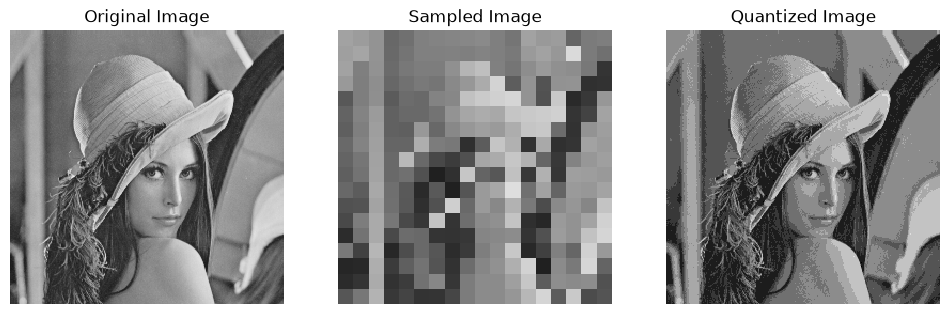

In [4]:
def imread_unicode(path, flags=cv2.IMREAD_GRAYSCALE):
    try:
        return cv2.imdecode(np.fromfile(path, dtype=np.uint8), flags)
    except (FileNotFoundError, OSError):
        return None

image_path = os.path.join(IMG_DIR, 'lena_gray_256.tif')
sampling_factor = 14
quantization_levels = 9

original_image = imread_unicode(image_path, cv2.IMREAD_GRAYSCALE)
if original_image is None:
    print(f"Error: Unable to load image at {image_path}")

sampled_image = sample_image(original_image, sampling_factor)
quantized_image = quantize_image(original_image, quantization_levels)

print('Original shape:', original_image.shape, '| Sampled shape:', sampled_image.shape)
print('Distinct gray levels after quantization:', len(np.unique(quantized_image)))
plot_images(original_image, sampled_image, quantized_image)

### Arithmetic operations (demo from the manual)
**Note:** the images are `uint8` (0–255). With `im1arr + im2arr`, any sum above 255 **wraps around**
(for example 200 + 100 = 300 → 44). That is why the manual's result has strange dark patches.
`cv2.add` **saturates** instead: anything above 255 becomes 255.

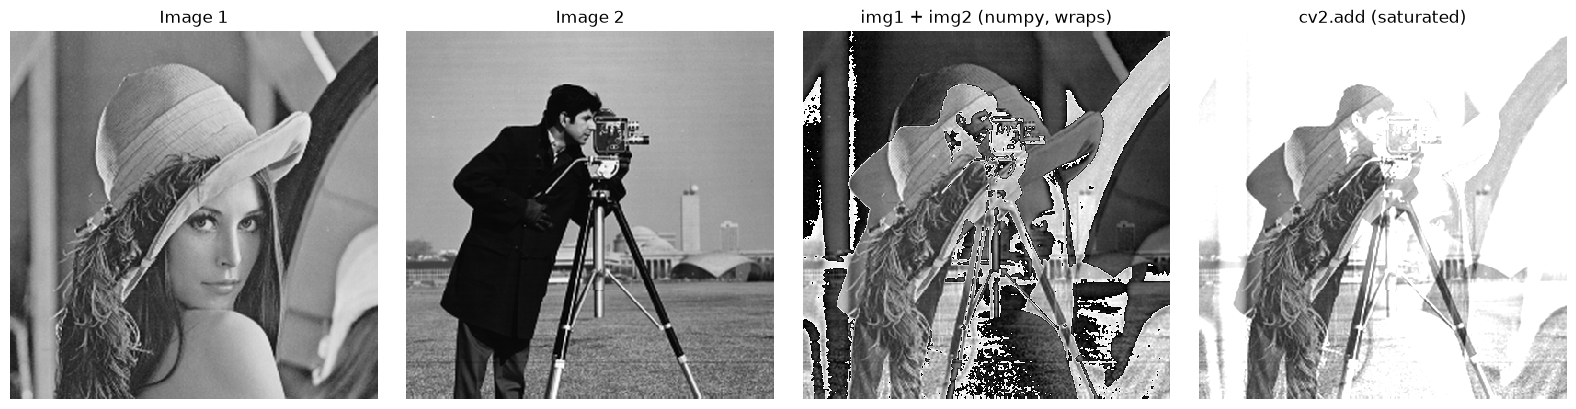

In [5]:
img1 = load_gray('lena_gray_256.tif')
img2 = load_gray('cameraman.tif', fallback_cameraman)

resize = (400, 400)
img1 = img1.resize(resize, Image.Resampling.LANCZOS)
img2 = img2.resize(resize, Image.Resampling.LANCZOS)

im1arr = np.asarray(img1)
im2arr = np.asarray(img2)

addition_wrap = im1arr + im2arr            # manual's version (overflow wraps)
addition_sat  = cv2.add(im1arr, im2arr)    # saturated version (clipped at 255)

show([im1arr, im2arr, addition_wrap, addition_sat],
     ['Image 1', 'Image 2', 'img1 + img2 (numpy, wraps)', 'cv2.add (saturated)'])

### Sets and logical operations (demo from the manual)
`|` is a bitwise OR. On binary images (0/255), OR is the same as the **union**.

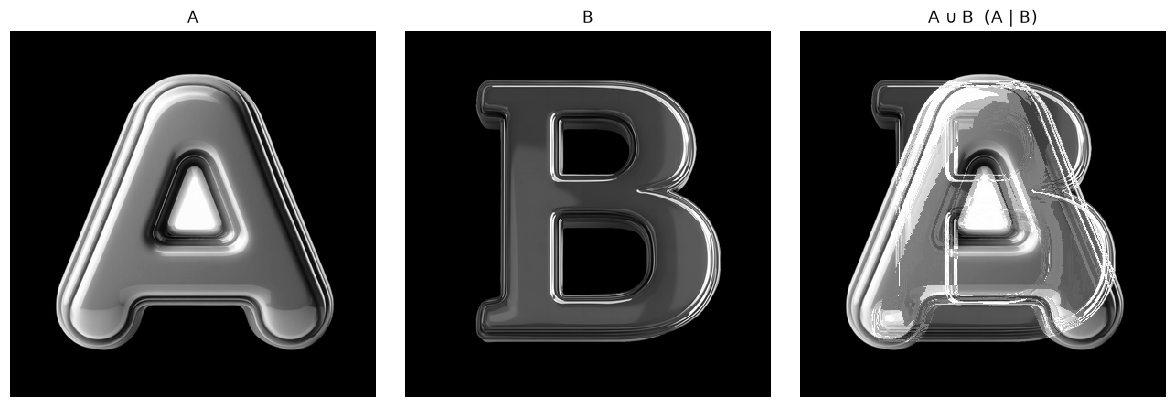

In [6]:
img3 = load_gray('A.png', fallback_A).resize(resize, Image.Resampling.LANCZOS)
img4 = load_gray('B.png', fallback_B).resize(resize, Image.Resampling.LANCZOS)
im3arr = np.asarray(img3)
im4arr = np.asarray(img4)

union = im4arr | im3arr
show([im3arr, im4arr, union], ['A', 'B', 'A ∪ B  (A | B)'])

---
# Task 1: Change the sampling and quantization parameters and observe the effects

### 1a. Sampling: different downsampling factors (quantization fixed at 256 levels)

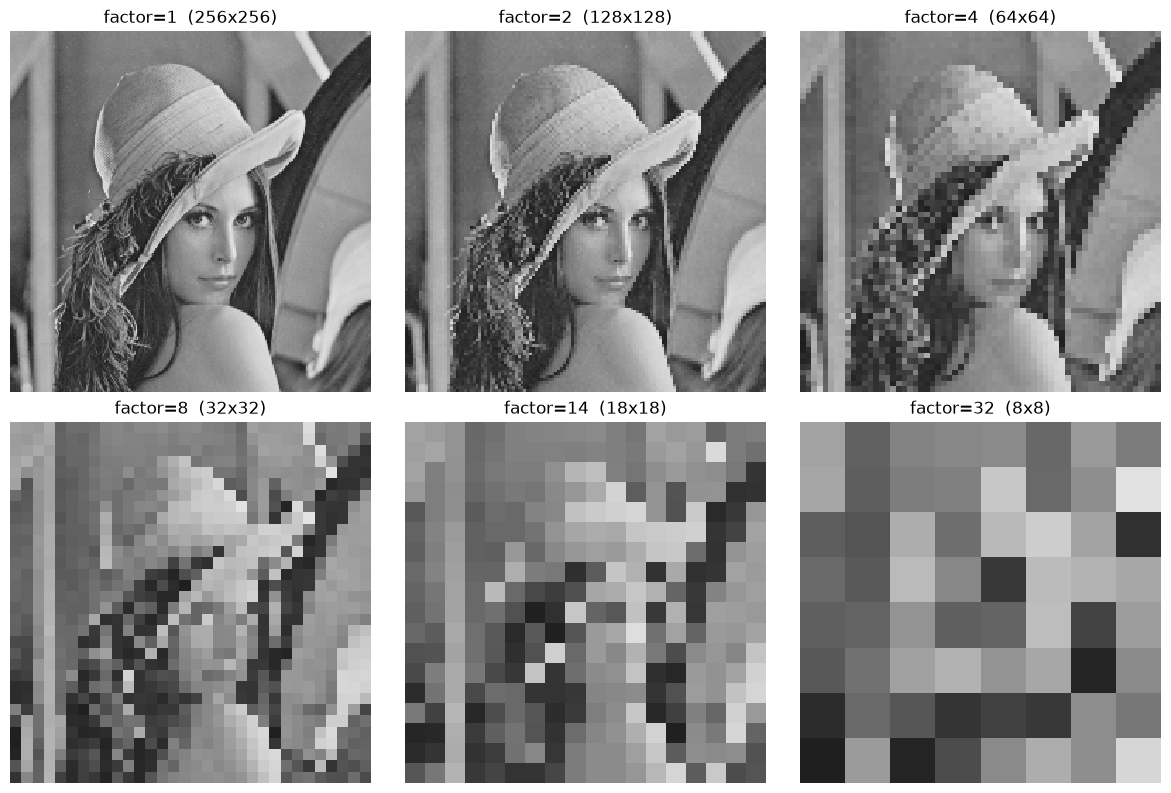

In [7]:
factors = [1, 2, 4, 8, 14, 32]
samples = [sample_image(original_image, f) for f in factors]
show(samples, [f'factor={f}  ({s.shape[1]}x{s.shape[0]})' for f, s in zip(factors, samples)], cols=3)

To compare fairly, scale each sampled image back to 256×256 with nearest neighbour, so the images are
the same size on the page and only the lost detail is different:

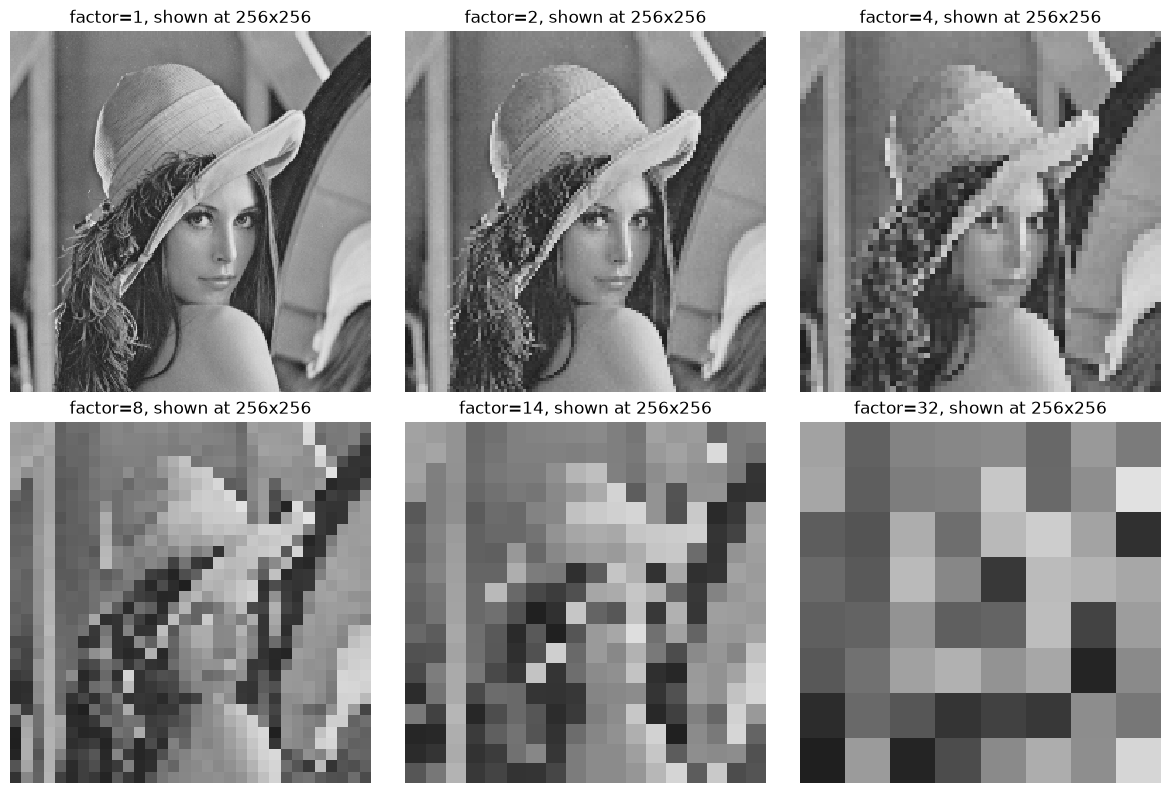

In [8]:
restored = [cv2.resize(s, original_image.shape[::-1], interpolation=cv2.INTER_NEAREST) for s in samples]
show(restored, [f'factor={f}, shown at 256x256' for f in factors], cols=3)

### 1b. Quantization: different numbers of gray levels (spatial size fixed at 256×256)

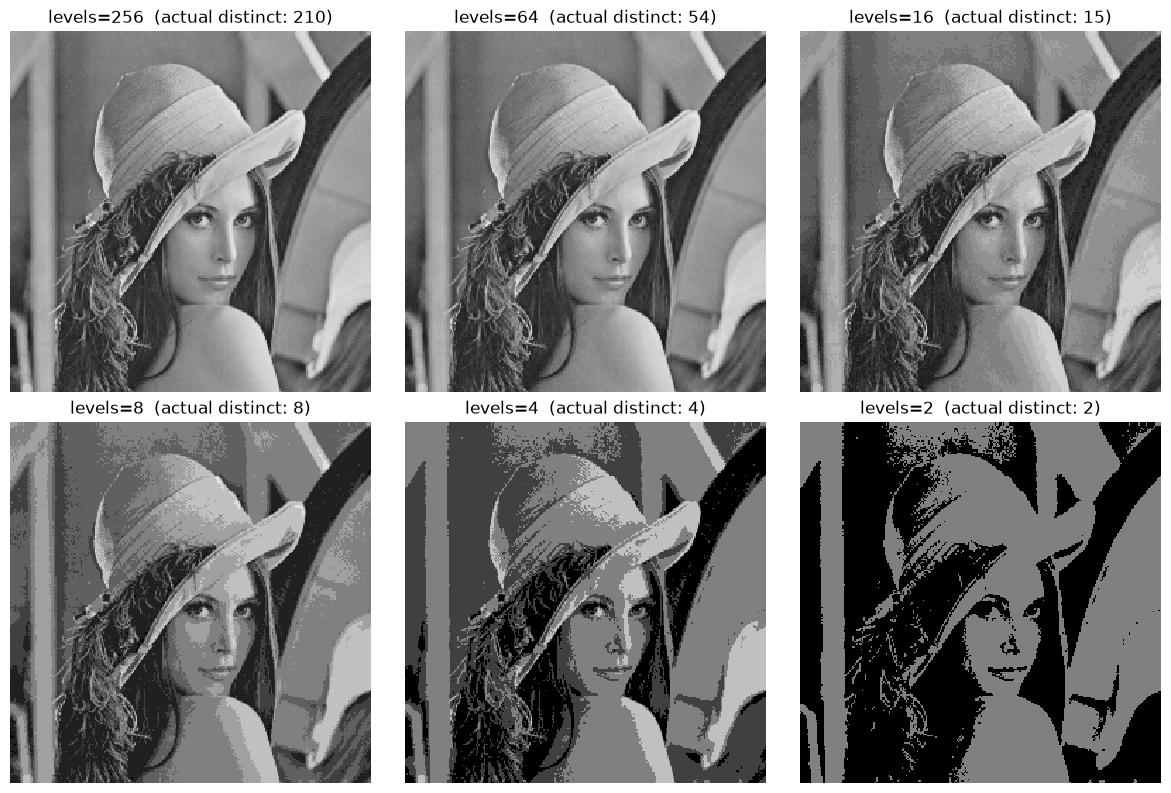

In [9]:
levels_list = [256, 64, 16, 8, 4, 2]
quants = [quantize_image(original_image, L) for L in levels_list]
show(quants, [f'levels={L}  (actual distinct: {len(np.unique(q))})' for L, q in zip(levels_list, quants)], cols=3)

### 1c. Try your own combinations with the original `plot_images` function

sampling_factor=2, quantization_levels=32


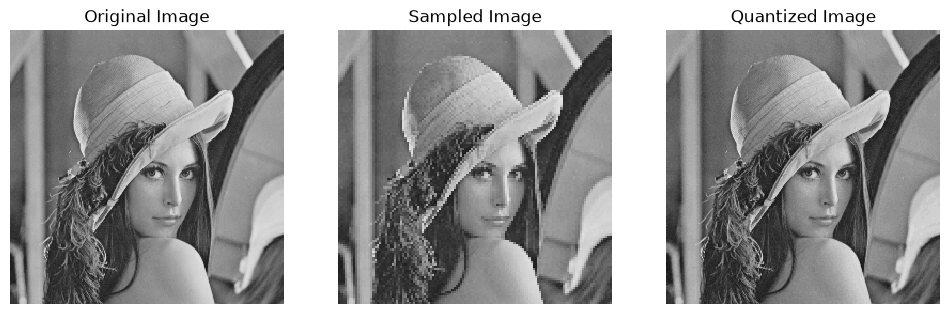

sampling_factor=4, quantization_levels=8


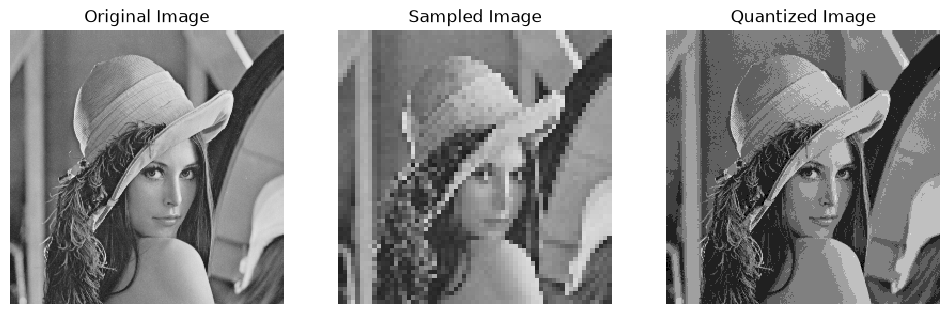

sampling_factor=8, quantization_levels=4


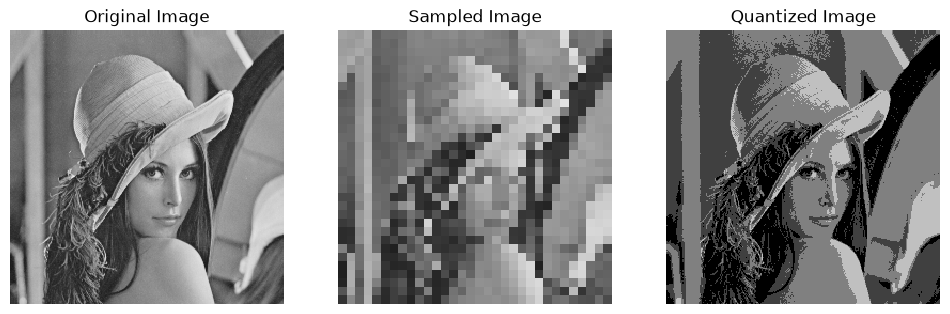

sampling_factor=20, quantization_levels=2


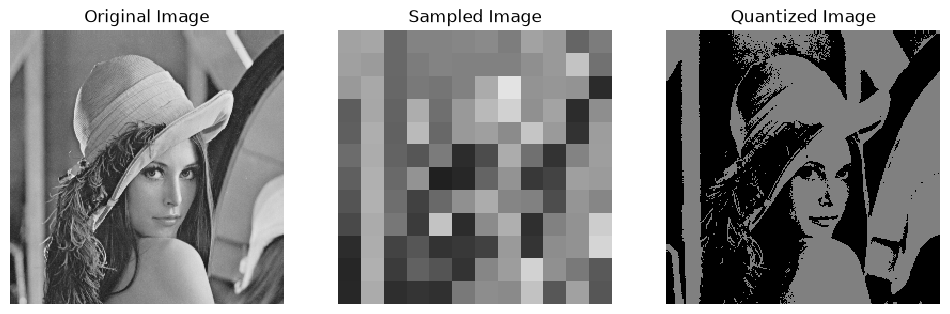

In [10]:
for sf, ql in [(2, 32), (4, 8), (8, 4), (20, 2)]:
    print(f'sampling_factor={sf}, quantization_levels={ql}')
    plot_images(original_image, sample_image(original_image, sf), quantize_image(original_image, ql))

### Task 1: Observations
**Sampling (spatial resolution):**
- A bigger sampling factor keeps fewer pixels: 256×256 → 128×128 → … → 8×8 for factor 32.
- At factors 2–4 the image still looks good. By 8–14 you see **pixelation** (a blocky, checkerboard look).
  Fine details such as hair, the edge of the hat and the eyes disappear, and diagonal edges look like **staircases (jaggies)**.
- At factor 32 you can no longer recognise the image. The detail is gone and cannot be recovered.
  Scaling the image back up only makes the blocks bigger.
- `INTER_NEAREST` keeps one pixel and throws its neighbours away, which also causes **aliasing**.

**Quantization (intensity resolution):**
- With 256 or 64 levels you can't see a difference. The eye can't separate that many gray levels.
- At about 16 levels, **false contouring** starts: smooth areas like the face, shoulder and background show visible bands.
- With 8 or 4 levels the banding is strong and the image looks posterised, but you can still recognise it.
- With 2 levels the image is almost binary (black and white).
- Quantization changes the **number of gray levels**, not the **image size**. Sampling does the opposite.

**Note on `quantize_image`:** the step size is `256 // levels`. When 256 is not divisible by `levels`, you get a few
levels than requested. For example, `levels=9` → step 28 → possible values 0, 28, …, 252 = **10** levels.
The image can also use fewer levels than that if its intensities don't cover the full 0–255 range
(this Lena only goes from 26 to 242, so 9 appear). The "actual distinct" count above shows this.
A version that gives exactly `levels` output values: `np.round(np.floor(image / 256 * levels) * 255 / (levels - 1)).astype(np.uint8)`.

---
# Task 2: Read two images, convert them to arrays, and perform operations

A: (400, 400) uint8 | B: (400, 400) uint8


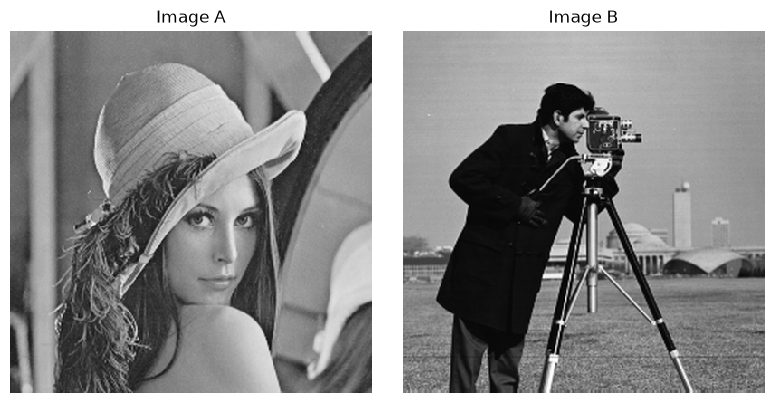

In [11]:
imgA = load_gray('lena_gray_256.tif').resize(resize, Image.Resampling.LANCZOS)
imgB = load_gray('cameraman.tif', fallback_cameraman).resize(resize, Image.Resampling.LANCZOS)

A = np.asarray(imgA)   # uint8 array, values 0-255
B = np.asarray(imgB)
print('A:', A.shape, A.dtype, '| B:', B.shape, B.dtype)
show([A, B], ['Image A', 'Image B'])

### 2.1 Subtract two images
With plain `A - B`, negative results wrap around (for example 10 − 20 = −10 → 246).
Here are three versions: the wrap-around, the **saturated** version (`cv2.subtract`, negatives → 0),
and the **absolute difference** `|A − B|`.

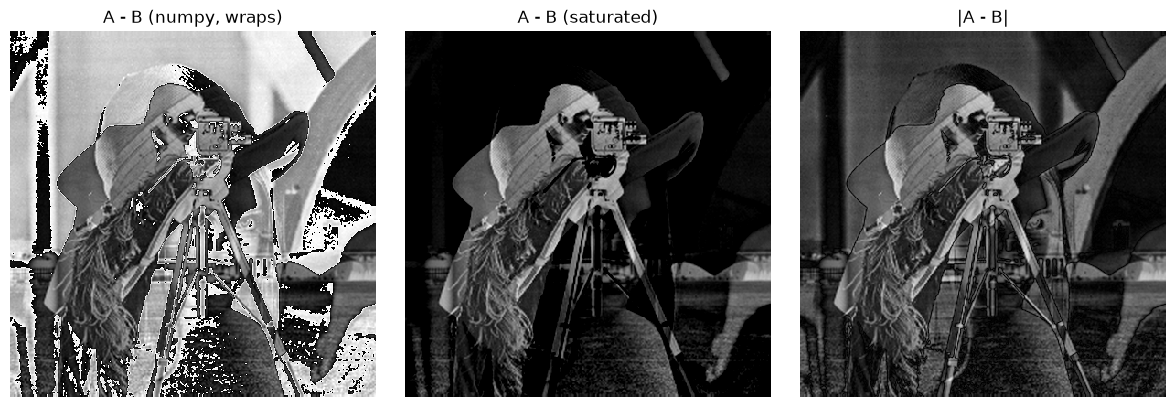

In [12]:
sub_wrap = A - B                                        # uint8 wrap-around
sub_sat  = cv2.subtract(A, B)                           # clipped: negatives -> 0
# same result using only numpy:
sub_np   = np.clip(A.astype(np.int16) - B.astype(np.int16), 0, 255).astype(np.uint8)
sub_abs  = cv2.absdiff(A, B)                            # |A - B|

assert np.array_equal(sub_sat, sub_np)
show([sub_wrap, sub_sat, sub_abs], ['A - B (numpy, wraps)', 'A - B (saturated)', '|A - B|'])
Image.fromarray(sub_sat).save('task2_subtraction.png')

### 2.2 Add a constant value of 175 to an image
Pixels above 80 would go past 255 (80 + 175 = 255), so we **clip** the result at 255.
The image gets much brighter, and every pixel ≥ 80 becomes pure white.

78.6% of pixels are saturated to 255


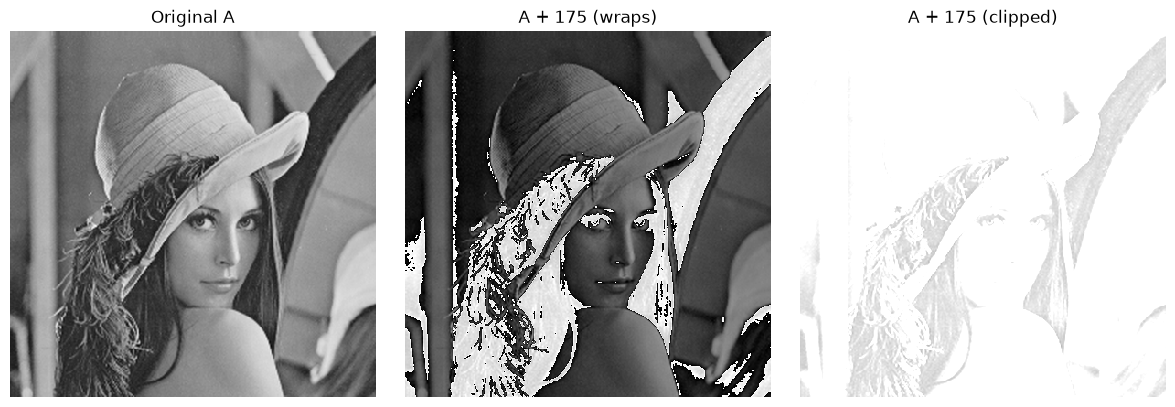

In [13]:
add_wrap = (A.astype(np.uint16) + 175).astype(np.uint8)                       # wraps (wrong)
add_175  = np.clip(A.astype(np.int16) + 175, 0, 255).astype(np.uint8)         # correct (saturated)
# equivalent in OpenCV:
add_cv   = cv2.add(A, np.full_like(A, 175))

assert np.array_equal(add_175, add_cv)
print(f'{(add_175 == 255).mean()*100:.1f}% of pixels are saturated to 255')
show([A, add_wrap, add_175], ['Original A', 'A + 175 (wraps)', 'A + 175 (clipped)'])
Image.fromarray(add_175).save('task2_add175.png')

### Set operations on gray-scale images
For gray-scale images, each pixel's value is treated as how much it "belongs" to the set
(Gonzalez & Woods, *Digital Image Processing*, §2.6):

| Operation | Formula (per pixel) |
|---|---|
| Complement | $A^c = 255 - A$ |
| Union | $A \cup B = \max(A, B)$ |
| **Intersection** | $A \cap B = \min(A, B)$ |
| **Difference** | $A - B = A \cap B^c = \min(A,\ 255 - B)$ |
| **Symmetric difference** | $A \triangle B = (A - B) \cup (B - A) = \max(\min(A, 255-B),\ \min(B, 255-A))$ |

In [14]:
def complement(X):         return 255 - X
def g_union(X, Y):         return np.maximum(X, Y)
def g_intersection(X, Y):  return np.minimum(X, Y)
def g_difference(X, Y):    return np.minimum(X, complement(Y))
def g_sym_difference(X, Y):return np.maximum(g_difference(X, Y), g_difference(Y, X))

### 2.3 Set difference (A − B)

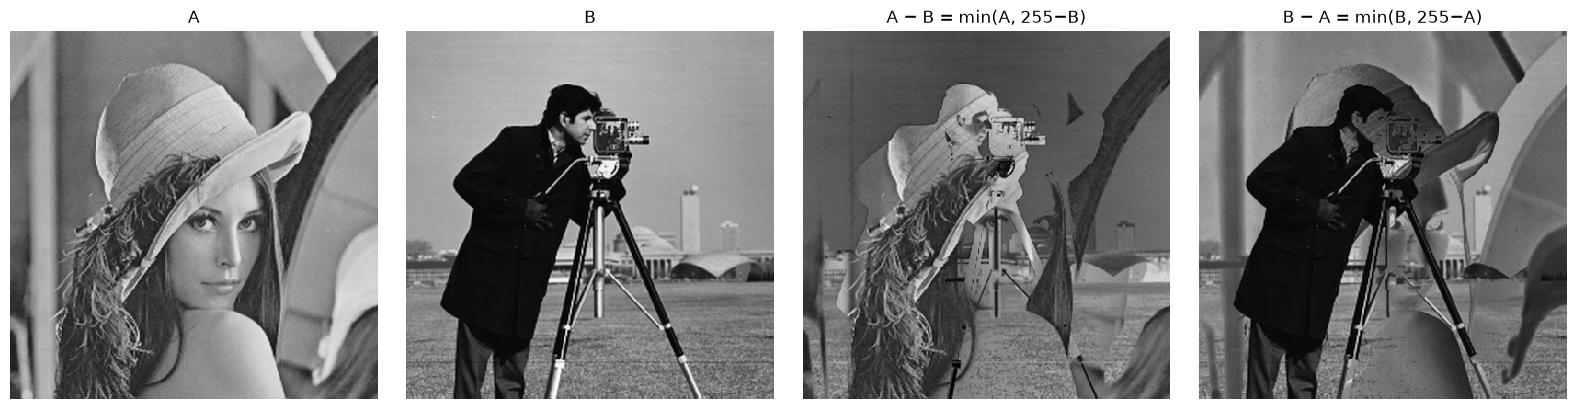

In [15]:
diff_AB = g_difference(A, B)
diff_BA = g_difference(B, A)
show([A, B, diff_AB, diff_BA], ['A', 'B', 'A − B = min(A, 255−B)', 'B − A = min(B, 255−A)'])
Image.fromarray(diff_AB).save('task2_set_difference.png')

### 2.4 Symmetric difference (A △ B)

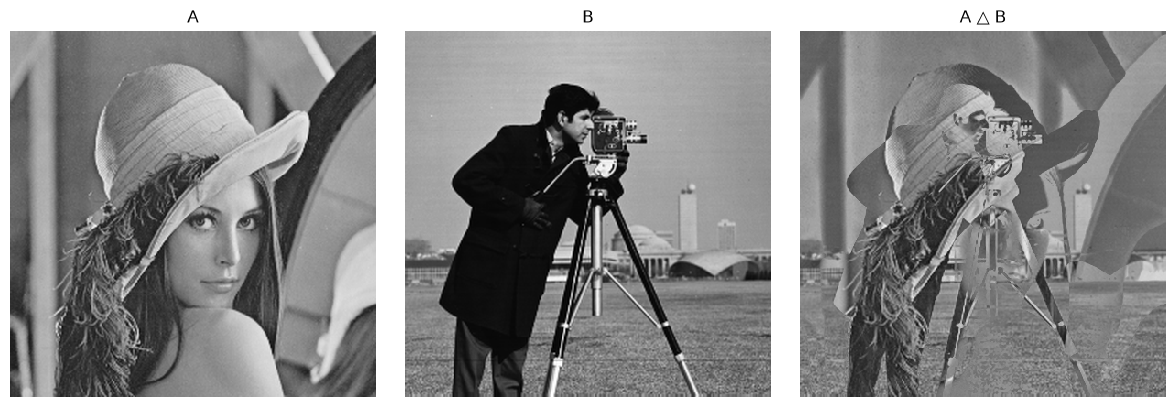

In [16]:
sym_diff = g_sym_difference(A, B)
show([A, B, sym_diff], ['A', 'B', 'A △ B'])
Image.fromarray(sym_diff).save('task2_symmetric_difference.png')

### 2.5 Intersection (A ∩ B)

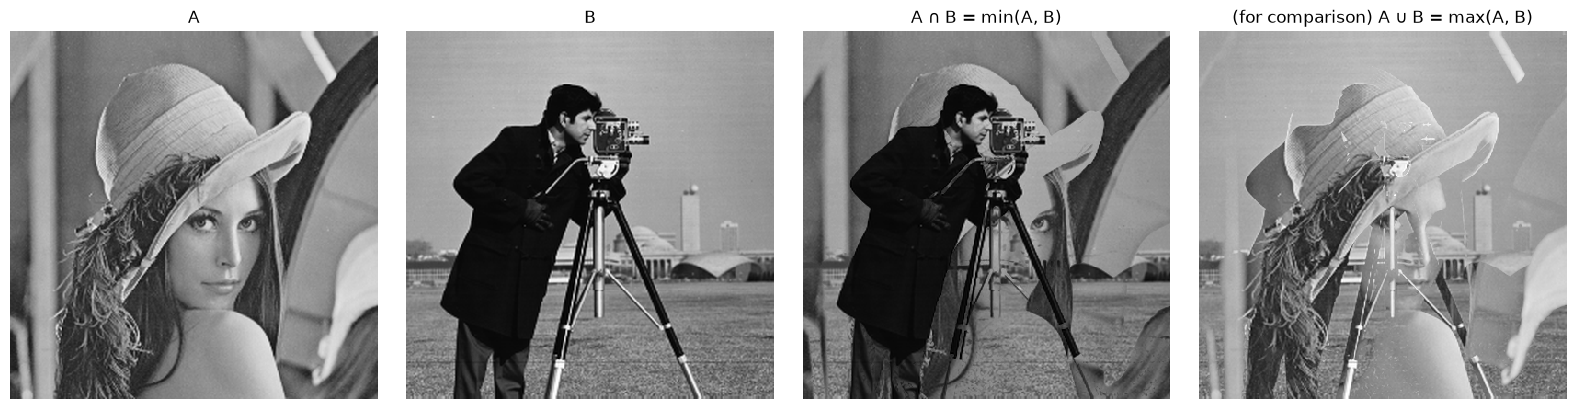

In [17]:
inter = g_intersection(A, B)
show([A, B, inter, g_union(A, B)], ['A', 'B', 'A ∩ B = min(A, B)', '(for comparison) A ∪ B = max(A, B)'])
Image.fromarray(inter).save('task2_intersection.png')

### Same gray-scale set operations on the letter images (A.png / B.png)

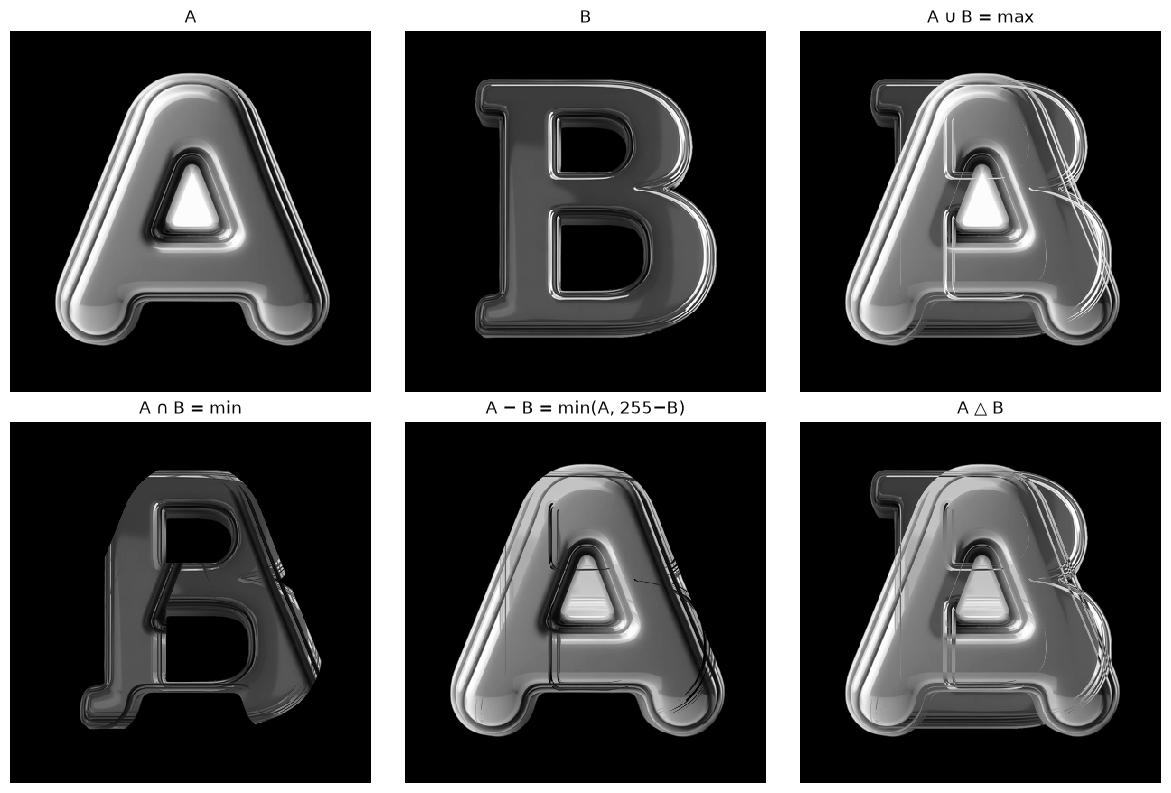

In [18]:
LA, LB = im3arr, im4arr   # gray-scale letters on a black background (400x400)
show([LA, LB, g_union(LA, LB), g_intersection(LA, LB), g_difference(LA, LB), g_sym_difference(LA, LB)],
     ['A', 'B', 'A ∪ B = max', 'A ∩ B = min', 'A − B = min(A, 255−B)', 'A △ B'], cols=3)

**Why A − B still looks almost like A:** the letter B is dark gray (low values), so `255 − B` is still bright,
and `min(A, 255 − B)` keeps most of A. Only B's bright highlight edges cut into A.
In the gray-scale definition, a dark pixel only "weakly" belongs to the set. The binary masks below show the
"all or nothing" version.

### Bonus: set operations on binary masks of the letters, using bitwise logic
Each mask comes from the PNG's transparency: 255 inside the letter, 0 outside.
For binary (0/255) images the gray-scale formulas above give the same result as the logical operators:
union = OR, intersection = AND, difference = A AND NOT B, symmetric difference = XOR.

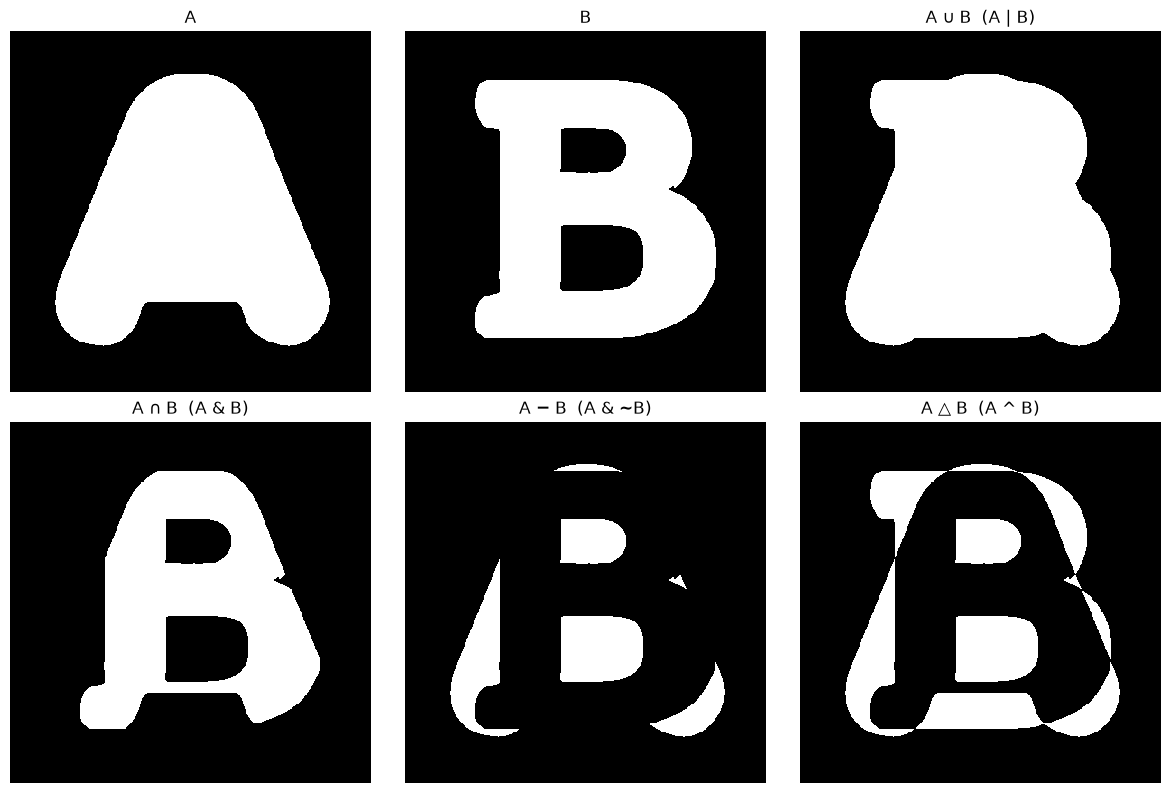

In [19]:
bA = load_mask('A.png', fallback_A)
bB = load_mask('B.png', fallback_B)

b_union = bA | bB
b_inter = bA & bB
b_diff  = bA & ~bB
b_xor   = bA ^ bB

# check: min/max versions give the same result on binary images
assert np.array_equal(b_inter, g_intersection(bA, bB))
assert np.array_equal(b_diff,  g_difference(bA, bB))
assert np.array_equal(b_xor,   g_sym_difference(bA, bB))

show([bA, bB, b_union, b_inter, b_diff, b_xor],
     ['A', 'B', 'A ∪ B  (A | B)', 'A ∩ B  (A & B)', 'A − B  (A & ~B)', 'A △ B  (A ^ B)'], cols=3)

### Task 2: Observations
- **Subtraction:** `uint8` wrap-around turns small negative differences into bright pixels. Saturated subtraction keeps
  only the areas where A is brighter than B. `|A−B|` highlights **all** differences, which is how change detection works.
- **Adding 175:** the image gets much brighter and loses contrast. Every pixel ≥ 80 clips to white, so detail in
  mid-tones and bright areas is lost. Without clipping, bright pixels wrap around and turn dark.
- **Intersection (min):** keeps a pixel bright only where **both** images are bright, so the result is darker overall.
- **Set difference (A − B):** keeps a pixel bright where A is bright **and** B is dark.
- **Symmetric difference:** bright where exactly **one** of the images is bright. On binary images it is the same as XOR.